In [ ]:
import os
import sys
# Add the parent directory to the Python path to allow module imports
sys.path.append(os.path.dirname(os.getcwd()))

import random
import numpy as np
import pandas as pd
import seaborn as sns
from pprint import pprint
from pathlib import Path
from matplotlib import pyplot as plt

import torch
from torchinfo import summary
from lightning import Trainer
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

from modules.datamodule import LungSoundDataModule
from modules.classifier import LungSoundClassifier
from modules.transforms import *

In [ ]:
PROJECT_ROOT = Path(os.path.dirname(os.getcwd()))
DATA_FOLDER = PROJECT_ROOT / "data" / "preprocessed"
if not os.path.exists(DATA_FOLDER):
    print(f"Data directory not found at {DATA_FOLDER}. Please ensure the data is downloaded and placed in the correct location.")

LOGS_FOLDER = PROJECT_ROOT / "logs"
if not os.path.exists(LOGS_FOLDER):
    os.makedirs(LOGS_FOLDER)

CHECKPOINTS_FOLDER = PROJECT_ROOT / "checkpoints"
if not os.path.exists(CHECKPOINTS_FOLDER):
    os.makedirs(CHECKPOINTS_FOLDER)

RESULTS_FOLDER = PROJECT_ROOT / "results"
if not os.path.exists(RESULTS_FOLDER):
    os.makedirs(RESULTS_FOLDER)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

torch.set_float32_matmul_precision("high")
%load_ext tensorboard

Using device: cuda


In [ ]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_input_size(dm: LungSoundDataModule) -> tuple:
    """
    Get the input size for the model based on a sample batch from the DataModule.
    Args:
        dm (LungSoundDataModule): The DataModule to sample from.
    Returns:
        input_size (tuple): Tuple representing the shape of the input data (e.g., (B, C, H, W)).
    """
    dm.setup()
    loader = dm.train_dataloader()
    batch = next(iter(loader))
    inputs, _, _ = batch
    return tuple(inputs.shape)


def save_results(model) -> None:
    """
    Save test results to a CSV file.
    Args:
        test_results (dict): Dictionary containing test metrics and results.
        path (Path | str): Path to the CSV file where results will be saved.
    """
    classes = model.hparams.dataset["classes"]
    probs_df = pd.DataFrame(model.test_results["probs"], columns=[f"prob_{cls}" for cls in classes])
    results_df = pd.DataFrame({
        "target": model.test_results["targets"],
        "pred": model.test_results["preds"],
    })
    info_df = pd.DataFrame(model.test_results["info"])
    results_df = pd.concat([results_df, probs_df, info_df], axis=1)
    path = RESULTS_FOLDER / f"{model.hparams['experiment']}_results.csv"
    results_df.to_csv(path, index=False)
    print(f"Test results saved to {path}")


def train_model(hparams: dict, debug: bool = False) -> LungSoundClassifier:
    """
    Train a model.
    Args:
        hparams (dict): Hyperparameters and configuration for the experiment. Trainer parameters:
        ```
        - experiment (str): Name of the experiment for logging and checkpointing.
        - checkpoint_monitor (str): Metric to monitor for checkpointing (e.g., "val_loss").
        - checkpoint_mode (str): Mode for checkpointing ("min" or "max").
        - early_stop_monitor (str): Metric to monitor for early stopping (e.g., "val_loss").
        - early_stop_mode (str): Mode for early stopping ("min" or "max").
        - patience (int): Number of epochs with no improvement after which training will be stopped.
        - max_epochs (int): Maximum number of training epochs.
        - precision (int): Precision for training (e.g., 16 for mixed precision).
        ```
        debug (bool): If True, dry run the training for quick debugging. Default is False.
    Returns:
        model (LungSoundClassifier): The trained model.
    """
    set_seed(hparams["seed"])

    # Display experiment hyperparameters
    print("Experiment hyperparameters:")
    pprint(hparams)

    # Initialize logger
    logger = TensorBoardLogger(
        save_dir=LOGS_FOLDER,
        name=hparams["experiment"],
    )

    # Initialize callbacks
    callbacks = []
    if not debug:
        checkpoint_callback = ModelCheckpoint(
            dirpath=CHECKPOINTS_FOLDER,
            filename=hparams["experiment"] + "-{epoch}-{val_loss:.2f}-{val_f1_micro:.2f}-{val_f1_macro:.2f}",
            monitor=hparams["checkpoint_monitor"],
            mode=hparams["checkpoint_mode"],
            save_top_k=3,
            verbose=True,
        )
        callbacks.append(checkpoint_callback)

        early_stopping_callback = EarlyStopping(
            monitor=hparams["early_stop_monitor"],
            mode=hparams["early_stop_mode"],
            patience=hparams["patience"],
            verbose=True,
        )
        callbacks.append(early_stopping_callback)

    # Initialize DataModule and Model
    dm = LungSoundDataModule(hparams, DATA_FOLDER)
    model = LungSoundClassifier(hparams)

    # Display model architecture
    input_shape = get_input_size(dm)
    print("Model Summary:\n")
    print(f"Input shape: {input_shape}")
    print(summary(model, input_size=input_shape))
    print("\n")

    # Initialize Trainer
    trainer = Trainer(
        accelerator="gpu" if DEVICE == "cuda" else "cpu",
        devices="auto",
        max_epochs=hparams["max_epochs"],
        precision=hparams["precision"],
        callbacks=callbacks,
        logger=logger,
        fast_dev_run=debug,
    )

    # Train the model
    trainer.fit(model, dm)

    # Test the model
    trainer.test(model, dm)

    # Save test results to a CSV
    save_results(model)

    return model

In [4]:
def show_metrics(targets: np.ndarray, preds: np.ndarray, probs: np.ndarray, class_names: list):
    """
    Display classification metrics including classification report, ROC AUC curve, Precision-Recall curve, and confusion matrix.
    Args:
        targets (np.ndarray): Array of true target labels.
        preds (np.ndarray): Array of predicted labels by the model.
        probs (np.ndarray): Array of predicted probabilities for each class.
        class_names (list): List of class names corresponding to the target labels.
    """
    # y_true in one-hot encoding format for multi-class metrics
    y_true = label_binarize(targets, classes=np.arange(len(class_names)))

    # Print classification report
    print("Classification Report:")
    print(classification_report(targets, preds, target_names=class_names))

    # Plot ROC curves
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, class_name in enumerate(class_names):
        RocCurveDisplay.from_predictions(y_true[:, i], probs[:, i], name=class_name, ax=ax)
    ax.set_title("ROC Curves")
    plt.show()

    # Plot Precision-Recall curves
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, class_name in enumerate(class_names):
        PrecisionRecallDisplay.from_predictions(y_true[:, i], probs[:, i], name=class_name, ax=ax)
    ax.set_title("Precision-Recall Curves")
    plt.show()

    # Plot confusion matrix
    cm = confusion_matrix(targets, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
    plt.title("Confusion Matrix")
    plt.show()


def evaluate_model(model: LungSoundClassifier, test_model: bool = False):
    """
    Evaluate the model on the test set and display metrics.
    Args:
        model (LungSoundClassifier): The trained model to evaluate.
        test_model (bool): If True, run the test loop to populate test results.
    """
    hparams = model.hparams
    if not hasattr(model, "test_results") or test_model:
        dm = LungSoundDataModule(model.hparams, DATA_FOLDER)
        trainer = Trainer(
            accelerator="gpu" if DEVICE == "cuda" else "cpu",
            devices="auto",
            precision=model.hparams["precision"],
            logger=False,
            enable_checkpointing=False,
            enable_progress_bar=False,
            enable_model_summary=False,
        )
        trainer.test(model, dm)

    targets = np.asarray(model.test_results["targets"])
    preds = np.asarray(model.test_results["preds"])
    probs = np.asarray(model.test_results["probs"])
    class_names = hparams.dataset["classes"]
    show_metrics(targets, preds, probs, class_names)

## Experiments with Inception V3

In [ ]:
hparams = {
    "experiment": "",   # TODO: Add experiment name to hparams

    # Callbacks
    "checkpoint_monitor": "val_f1_macro",
    "checkpoint_mode": "max",
    "early_stop_monitor": "val_f1_macro",
    "early_stop_mode": "max",
    "patience": 10,

    # Training
    "max_epochs": 100,
    "precision": "16-mixed",
    "seed": 42,

    # DataModule
    "batch_size": 32,
    "num_workers": 8,
    "sampler": None,

    # Dataset
    "dataset": {
        "name": "Combined_ICBHI_KAUH",
        "classes": [
            "Asthma",
            "Bronchiectasis",
            "Bronchiolitis",
            "COPD",
            "Healthy",
            "Lung Fibrosis",
            "Pneumonia",
            "URTI",
        ],
        "feature_extractor": "",    # TODO: Add feature extractor to hparams
        "num_channels": "",         # TODO: Add number of channels to hparams
    },

    # Model
    "model": {
        "name": "inception_v3",
        "pretrained": None,
        "freeze_layers": False,
    },

    # Optimization
    "criterion": "CrossEntropyLoss",
    "optimizer": "AdamW",
    "learning_rate": 0.0001,
    "weight_decay": 0.00001,
    "momentum": None,
    "lr_scheduler": "StepLR",
    "step_size": 7,
    "gamma": 0.1,
}

### STFT

In [ ]:
hparams["experiment"] = "inception_v3_combined_8-classes_STFT"
hparams["dataset"]["feature_extractor"] = "STFT"
hparams["dataset"]["num_channels"] = 1
model = train_model(hparams)

Experiment hyperparameters:
{'batch_size': 32,
 'checkpoint_mode': 'max',
 'checkpoint_monitor': 'val_f1_macro',
 'criterion': 'CrossEntropyLoss',
 'dataset': {'classes': ['Asthma',
                         'Bronchiectasis',
                         'Bronchiolitis',
                         'COPD',
                         'Healthy',
                         'Lung Fibrosis',
                         'Pneumonia',
                         'URTI'],
             'feature_extractor': 'STFT',
             'name': 'Combined_ICBHI_KAUH',
             'num_channels': 1},
 'early_stop_mode': 'max',
 'early_stop_monitor': 'val_f1_macro',
 'experiment': 'inception_v3_combined_8-classes_STFT',
 'gamma': 0.1,
 'learning_rate': 0.0001,
 'lr_scheduler': 'StepLR',
 'max_epochs': 100,
 'model': {'freeze_layers': False, 'name': 'inception_v3', 'pretrained': None},
 'momentum': None,
 'num_workers': 8,
 'optimizer': 'AdamW',
 'patience': 10,
 'precision': '16-mixed',
 'sampler': None,
 'seed': 42,
 'step_

/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


Model Summary:

Input shape: (32, 1, 1025, 216)


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

   | Name           | Type               | Params | Mode  | FLOPs
-----------------------------------------------------------------------
0  | model          | Inception3         | 21.8 M | train | 0    
1  | criterion      | CrossEntropyLoss   | 0      | train | 0    
2  | train_f1_macro | MulticlassF1Score  | 0      | train | 0 

Layer (type:depth-idx)                   Output Shape              Param #
LungSoundClassifier                      [32, 8]                   --
├─Inception3: 1-1                        [32, 8]                   --
│    └─BasicConv2d: 2-1                  [32, 32, 512, 107]        --
│    │    └─Conv2d: 3-1                  [32, 32, 512, 107]        288
│    │    └─BatchNorm2d: 3-2             [32, 32, 512, 107]        64
│    └─BasicConv2d: 2-2                  [32, 32, 510, 105]        --
│    │    └─Conv2d: 3-3                  [32, 32, 510, 105]        9,216
│    │    └─BatchNorm2d: 3-4             [32, 32, 510, 105]        64
│    └─BasicConv2d: 2-3                  [32, 64, 510, 105]        --
│    │    └─Conv2d: 3-5                  [32, 64, 510, 105]        18,432
│    │    └─BatchNorm2d: 3-6             [32, 64, 510, 105]        128
│    └─MaxPool2d: 2-4                    [32, 64, 254, 52]         --
│    └─BasicConv2d: 2-5                  [32, 80, 254, 52]         --
│    │

...

Epoch 26, global step 3159: 'val_f1_macro' was not in top 3


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_f1_macro did not improve in the last 10 records. Best score: 0.497. Signaling Trainer to stop.
Epoch 27, global step 3276: 'val_f1_macro' was not in top 3
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         Test metric                 DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       test_Asthma_f1             0.47058823704719543
    test_Asthma_precision         0.5454545617103577
     test_Asthma_recall           0.4137931168079376
   test_Bronchiectasis_f1         0.6666666865348816
test_Bronchiectasis_precision             1.0
 test_Bronchiectasis_recall               0.5
    test_Bronchiolitis_f1         0.3333333432674408
test_Bronchiolitis_precision              1.0
  test_Bronchiolitis_recall       0.20000000298023224
        test_COPD_f1              0.9449929594993591
     test_COPD_precision          0.9305555820465088
      test_COPD_recall            0.9598853588104248
       test_Healthy_f1            0.6464646458625793
   test_Healthy_precision         0.59

Classification Report:
                precision    recall  f1-score   support

        Asthma       0.55      0.41      0.47        29
Bronchiectasis       1.00      0.50      0.67         6
 Bronchiolitis       1.00      0.20      0.33         5
          COPD       0.93      0.96      0.94       349
       Healthy       0.59      0.71      0.65        45
 Lung Fibrosis       0.00      0.00      0.00         3
     Pneumonia       0.37      0.35      0.36        20
          URTI       0.29      0.22      0.25         9

      accuracy                           0.84       466
     macro avg       0.59      0.42      0.46       466
  weighted avg       0.83      0.84      0.83       466



/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

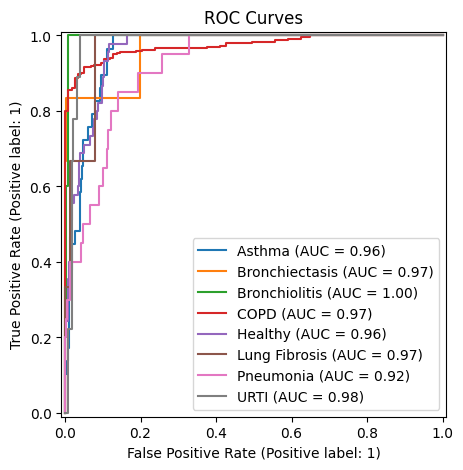

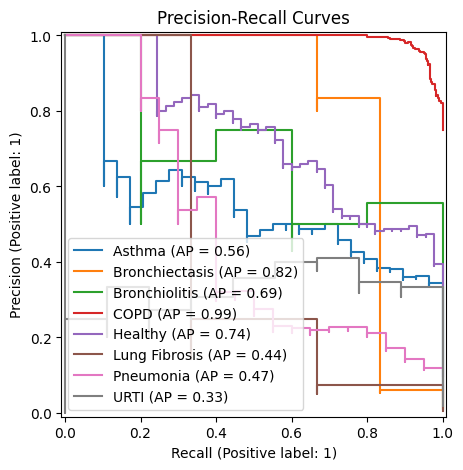

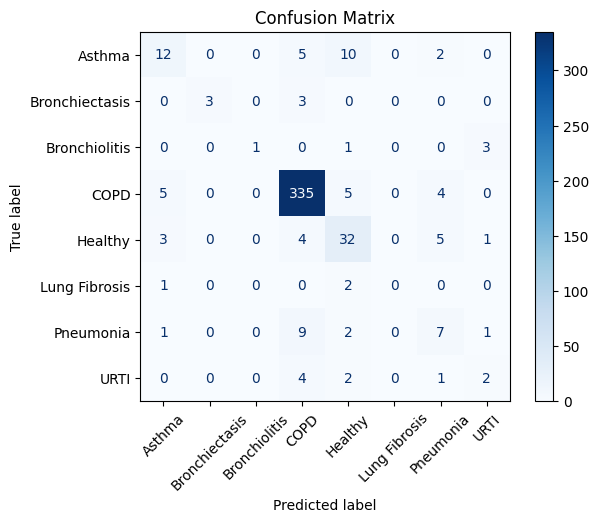

In [7]:
evaluate_model(model)

### MelSpectogram

In [ ]:
hparams["experiment"] = "inception_v3_combined_8-classes_MelSpectogram"
hparams["dataset"]["feature_extractor"] = "MelSpectogram"
hparams["dataset"]["num_channels"] = 1
model = train_model(hparams)

Experiment hyperparameters:
{'batch_size': 32,
 'checkpoint_mode': 'max',
 'checkpoint_monitor': 'val_f1_macro',
 'criterion': 'CrossEntropyLoss',
 'dataset': {'classes': ['Asthma',
                         'Bronchiectasis',
                         'Bronchiolitis',
                         'COPD',
                         'Healthy',
                         'Lung Fibrosis',
                         'Pneumonia',
                         'URTI'],
             'feature_extractor': 'MelSpectrogram',
             'name': 'Combined_ICBHI_KAUH',
             'num_channels': 1},
 'early_stop_mode': 'max',
 'early_stop_monitor': 'val_f1_macro',
 'experiment': 'inception_v3_combined_8-classes_MelSpectogram',
 'gamma': 0.1,
 'learning_rate': 0.0001,
 'lr_scheduler': 'StepLR',
 'max_epochs': 100,
 'model': {'freeze_layers': False, 'name': 'inception_v3', 'pretrained': None},
 'momentum': None,
 'num_workers': 8,
 'optimizer': 'AdamW',
 'patience': 10,
 'precision': '16-mixed',
 'sampler': None,
 

/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


Model Summary:

Input shape: (32, 1, 128, 216)


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/leticialopes/Projects/IA901/IA901_Project/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

   | Name           | Type               | Params | Mode  | FLOPs
-------------------------------

Layer (type:depth-idx)                   Output Shape              Param #
LungSoundClassifier                      [32, 8]                   --
├─Inception3: 1-1                        [32, 8]                   --
│    └─BasicConv2d: 2-1                  [32, 32, 63, 107]         --
│    │    └─Conv2d: 3-1                  [32, 32, 63, 107]         288
│    │    └─BatchNorm2d: 3-2             [32, 32, 63, 107]         64
│    └─BasicConv2d: 2-2                  [32, 32, 61, 105]         --
│    │    └─Conv2d: 3-3                  [32, 32, 61, 105]         9,216
│    │    └─BatchNorm2d: 3-4             [32, 32, 61, 105]         64
│    └─BasicConv2d: 2-3                  [32, 64, 61, 105]         --
│    │    └─Conv2d: 3-5                  [32, 64, 61, 105]         18,432
│    │    └─BatchNorm2d: 3-6             [32, 64, 61, 105]         128
│    └─MaxPool2d: 2-4                    [32, 64, 30, 52]          --
│    └─BasicConv2d: 2-5                  [32, 80, 30, 52]          --
│    │

...

Epoch 29, global step 3510: 'val_f1_macro' reached 0.44876 (best 0.45222), saving model to '/home/leticialopes/Projects/IA901/IA901_Project/checkpoints/inception_v3_combined_8-classes_MelSpectogram-epoch=29-val_loss=0.50-val_f1_micro=0.83-val_f1_macro=0.45.ckpt' as top 3


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_f1_macro did not improve in the last 10 records. Best score: 0.452. Signaling Trainer to stop.
Epoch 30, global step 3627: 'val_f1_macro' was not in top 3
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         Test metric                 DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       test_Asthma_f1                     0.5
    test_Asthma_precision         0.4571428596973419
     test_Asthma_recall           0.5517241358757019
   test_Bronchiectasis_f1                 0.5
test_Bronchiectasis_precision             1.0
 test_Bronchiectasis_recall       0.3333333432674408
    test_Bronchiolitis_f1                 0.0
test_Bronchiolitis_precision              0.0
  test_Bronchiolitis_recall               0.0
        test_COPD_f1              0.9301676154136658
     test_COPD_precision          0.9073569774627686
      test_COPD_recall            0.9541547298431396
       test_Healthy_f1                    0.5
   test_Healthy_precision         0.47058823704719543
     test_Heal

Classification Report:
                precision    recall  f1-score   support

        Asthma       0.46      0.55      0.50        29
Bronchiectasis       1.00      0.33      0.50         6
 Bronchiolitis       0.00      0.00      0.00         5
          COPD       0.91      0.95      0.93       349
       Healthy       0.47      0.53      0.50        45
 Lung Fibrosis       0.00      0.00      0.00         3
     Pneumonia       0.43      0.15      0.22        20
          URTI       0.00      0.00      0.00         9

      accuracy                           0.81       466
     macro avg       0.41      0.32      0.33       466
  weighted avg       0.78      0.81      0.79       466



/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

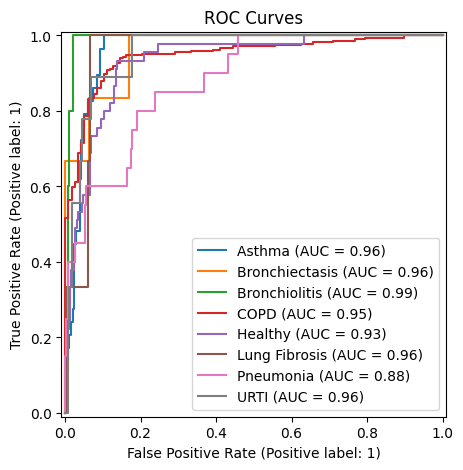

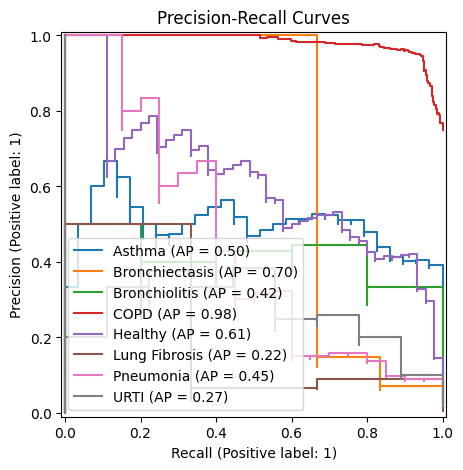

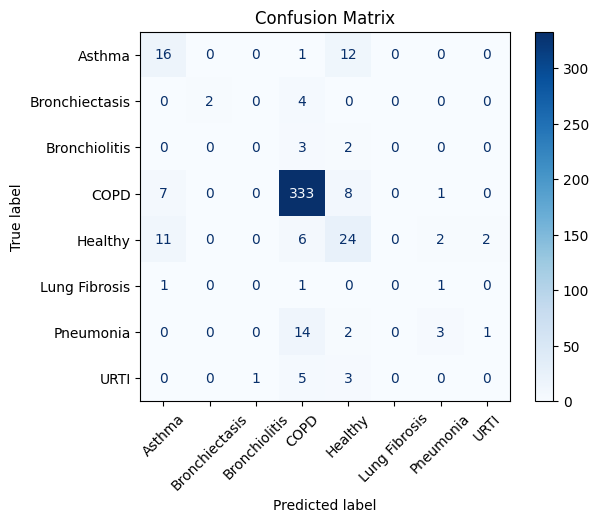

In [7]:
evaluate_model(model)

### MFCC

In [ ]:
hparams["experiment"] = "inception_v3_combined_8-classes_MFCC"
hparams["dataset"]["feature_extractor"] = "MFCC"
hparams["dataset"]["num_channels"] = 1
model = train_model(hparams)

Experiment hyperparameters:
{'batch_size': 32,
 'checkpoint_mode': 'max',
 'checkpoint_monitor': 'val_f1_macro',
 'criterion': 'CrossEntropyLoss',
 'dataset': {'classes': ['Asthma',
                         'Bronchiectasis',
                         'Bronchiolitis',
                         'COPD',
                         'Healthy',
                         'Lung Fibrosis',
                         'Pneumonia',
                         'URTI'],
             'feature_extractor': 'MFCC',
             'name': 'Combined_ICBHI_KAUH',
             'num_channels': 1},
 'early_stop_mode': 'max',
 'early_stop_monitor': 'val_f1_macro',
 'experiment': 'inception_v3_combined_8-classes_MFCC',
 'gamma': 0.1,
 'learning_rate': 0.0001,
 'lr_scheduler': 'StepLR',
 'max_epochs': 100,
 'model': {'freeze_layers': False, 'name': 'inception_v3', 'pretrained': None},
 'momentum': None,
 'num_workers': 8,
 'optimizer': 'AdamW',
 'patience': 10,
 'precision': '16-mixed',
 'sampler': None,
 'seed': 42,
 'step_

/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/leticialopes/Projects/IA901/IA901_Project/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_D

Model Summary:

Input shape: (32, 1, 128, 216)
Layer (type:depth-idx)                   Output Shape              Param #
LungSoundClassifier                      [32, 8]                   --
├─Inception3: 1-1                        [32, 8]                   --
│    └─BasicConv2d: 2-1                  [32, 32, 63, 107]         --
│    │    └─Conv2d: 3-1                  [32, 32, 63, 107]         288
│    │    └─BatchNorm2d: 3-2             [32, 32, 63, 107]         64
│    └─BasicConv2d: 2-2                  [32, 32, 61, 105]         --
│    │    └─Conv2d: 3-3                  [32, 32, 61, 105]         9,216
│    │    └─BatchNorm2d: 3-4             [32, 32, 61, 105]         64
│    └─BasicConv2d: 2-3                  [32, 64, 61, 105]         --
│    │    └─Conv2d: 3-5                  [32, 64, 61, 105]         18,432
│    │    └─BatchNorm2d: 3-6             [32, 64, 61, 105]         128
│    └─MaxPool2d: 2-4                    [32, 64, 30, 52]          --
│    └─BasicConv2d: 2-5      

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

Epoch 31, global step 3744: 'val_f1_macro' was not in top 3


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_f1_macro did not improve in the last 10 records. Best score: 0.631. Signaling Trainer to stop.
Epoch 32, global step 3861: 'val_f1_macro' was not in top 3
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         Test metric                 DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       test_Asthma_f1             0.6000000238418579
    test_Asthma_precision         0.7142857313156128
     test_Asthma_recall            0.517241358757019
   test_Bronchiectasis_f1         0.9090909361839294
test_Bronchiectasis_precision             1.0
 test_Bronchiectasis_recall       0.8333333134651184
    test_Bronchiolitis_f1         0.6666666865348816
test_Bronchiolitis_precision             0.75
  test_Bronchiolitis_recall       0.6000000238418579
        test_COPD_f1              0.9579831957817078
     test_COPD_precision          0.9369863271713257
      test_COPD_recall            0.9799426794052124
       test_Healthy_f1            0.6881720423698425
   test_Healthy_precision        

Classification Report:
                precision    recall  f1-score   support

        Asthma       0.71      0.52      0.60        29
Bronchiectasis       1.00      0.83      0.91         6
 Bronchiolitis       0.75      0.60      0.67         5
          COPD       0.94      0.98      0.96       349
       Healthy       0.67      0.71      0.69        45
 Lung Fibrosis       0.00      0.00      0.00         3
     Pneumonia       0.73      0.55      0.63        20
          URTI       0.50      0.44      0.47         9

      accuracy                           0.88       466
     macro avg       0.66      0.58      0.62       466
  weighted avg       0.87      0.88      0.88       466



/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

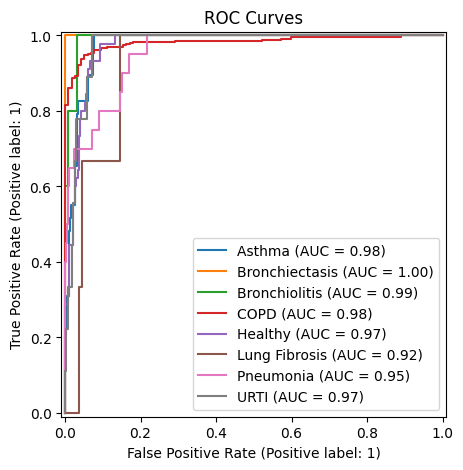

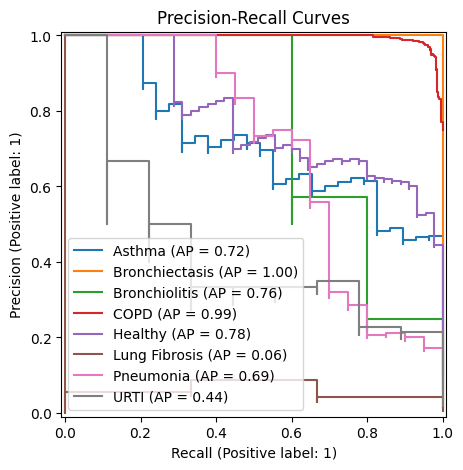

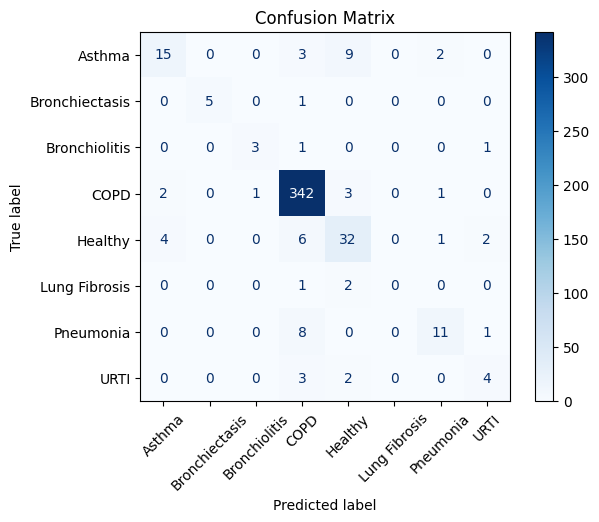

In [9]:
evaluate_model(model)

### MFCCDelta

In [ ]:
hparams["experiment"] = "inception_v3_combined_8-classes_MFCCDelta"
hparams["dataset"]["feature_extractor"] = "MFCCDelta"
hparams["dataset"]["num_channels"] = 1
model = train_model(hparams)

Experiment hyperparameters:
{'batch_size': 32,
 'checkpoint_mode': 'max',
 'checkpoint_monitor': 'val_f1_macro',
 'criterion': 'CrossEntropyLoss',
 'dataset': {'classes': ['Asthma',
                         'Bronchiectasis',
                         'Bronchiolitis',
                         'COPD',
                         'Healthy',
                         'Lung Fibrosis',
                         'Pneumonia',
                         'URTI'],
             'feature_extractor': 'MFCCDelta',
             'name': 'Combined_ICBHI_KAUH',
             'num_channels': 1},
 'early_stop_mode': 'max',
 'early_stop_monitor': 'val_f1_macro',
 'experiment': 'inception_v3_combined_8-classes_MFCCDelta',
 'gamma': 0.1,
 'learning_rate': 0.0001,
 'lr_scheduler': 'StepLR',
 'max_epochs': 100,
 'model': {'freeze_layers': False, 'name': 'inception_v3', 'pretrained': None},
 'momentum': None,
 'num_workers': 8,
 'optimizer': 'AdamW',
 'patience': 10,
 'precision': '16-mixed',
 'sampler': None,
 'seed': 4

/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/leticialopes/Projects/IA901/IA901_Project/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_D

Model Summary:

Input shape: (32, 1, 128, 216)
Layer (type:depth-idx)                   Output Shape              Param #
LungSoundClassifier                      [32, 8]                   --
├─Inception3: 1-1                        [32, 8]                   --
│    └─BasicConv2d: 2-1                  [32, 32, 63, 107]         --
│    │    └─Conv2d: 3-1                  [32, 32, 63, 107]         288
│    │    └─BatchNorm2d: 3-2             [32, 32, 63, 107]         64
│    └─BasicConv2d: 2-2                  [32, 32, 61, 105]         --
│    │    └─Conv2d: 3-3                  [32, 32, 61, 105]         9,216
│    │    └─BatchNorm2d: 3-4             [32, 32, 61, 105]         64
│    └─BasicConv2d: 2-3                  [32, 64, 61, 105]         --
│    │    └─Conv2d: 3-5                  [32, 64, 61, 105]         18,432
│    │    └─BatchNorm2d: 3-6             [32, 64, 61, 105]         128
│    └─MaxPool2d: 2-4                    [32, 64, 30, 52]          --
│    └─BasicConv2d: 2-5      

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

Epoch 13, global step 1638: 'val_f1_macro' was not in top 3


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_f1_macro did not improve in the last 10 records. Best score: 0.300. Signaling Trainer to stop.
Epoch 14, global step 1755: 'val_f1_macro' reached 0.26757 (best 0.29977), saving model to '/home/leticialopes/Projects/IA901/IA901_Project/checkpoints/inception_v3_combined_8-classes_MFCCDelta-epoch=14-val_loss=0.58-val_f1_micro=0.81-val_f1_macro=0.27.ckpt' as top 3
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         Test metric                 DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       test_Asthma_f1             0.6666666865348816
    test_Asthma_precision         0.6451612710952759
     test_Asthma_recall           0.6896551847457886
   test_Bronchiectasis_f1                 0.0
test_Bronchiectasis_precision             0.0
 test_Bronchiectasis_recall               0.0
    test_Bronchiolitis_f1                 0.0
test_Bronchiolitis_precision              0.0
  test_Bronchiolitis_recall               0.0
        test_COPD_f1              0.9213483333587646
     test_COPD_precision          0.9035812616348267
      test_COPD_recall             0.939828097820282
       test_Healthy_f1                    0.5
   test_Healthy_precision         0.4285714328289032
     test_Healt

Classification Report:
                precision    recall  f1-score   support

        Asthma       0.65      0.69      0.67        29
Bronchiectasis       0.00      0.00      0.00         6
 Bronchiolitis       0.00      0.00      0.00         5
          COPD       0.90      0.94      0.92       349
       Healthy       0.43      0.60      0.50        45
 Lung Fibrosis       0.00      0.00      0.00         3
     Pneumonia       0.50      0.05      0.09        20
          URTI       0.14      0.11      0.12         9

      accuracy                           0.81       466
     macro avg       0.33      0.30      0.29       466
  weighted avg       0.78      0.81      0.79       466



/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

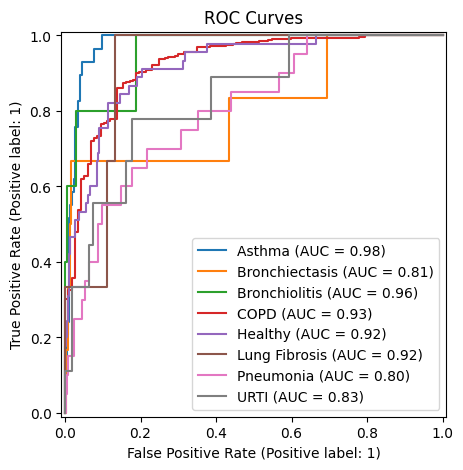

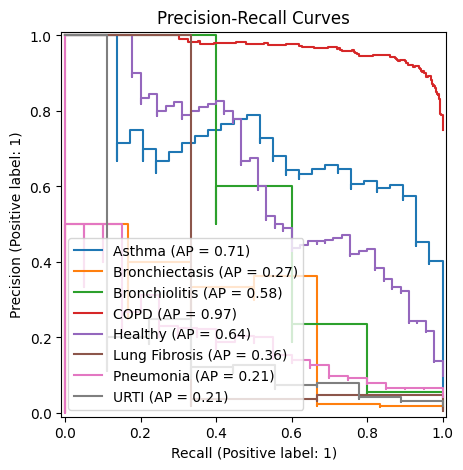

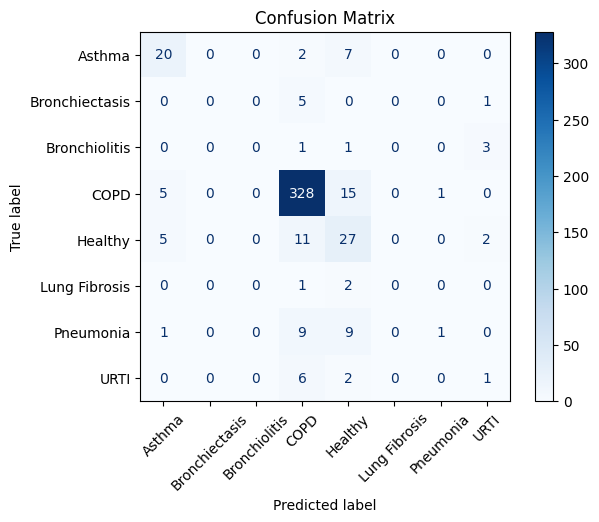

In [11]:
evaluate_model(model)

### Chroma

In [ ]:
hparams["experiment"] = "inception_v3_combined_8-classes_Chroma"
hparams["dataset"]["feature_extractor"] = "Chroma"
hparams["dataset"]["num_channels"] = 1
model = train_model(hparams)

Experiment hyperparameters:
{'batch_size': 32,
 'checkpoint_mode': 'max',
 'checkpoint_monitor': 'val_f1_macro',
 'criterion': 'CrossEntropyLoss',
 'dataset': {'classes': ['Asthma',
                         'Bronchiectasis',
                         'Bronchiolitis',
                         'COPD',
                         'Healthy',
                         'Lung Fibrosis',
                         'Pneumonia',
                         'URTI'],
             'feature_extractor': 'Chroma',
             'name': 'Combined_ICBHI_KAUH',
             'num_channels': 1},
 'early_stop_mode': 'max',
 'early_stop_monitor': 'val_f1_macro',
 'experiment': 'inception_v3_combined_8-classes_Chroma',
 'gamma': 0.1,
 'learning_rate': 0.0001,
 'lr_scheduler': 'StepLR',
 'max_epochs': 100,
 'model': {'freeze_layers': False, 'name': 'inception_v3', 'pretrained': None},
 'momentum': None,
 'num_workers': 8,
 'optimizer': 'AdamW',
 'patience': 10,
 'precision': '16-mixed',
 'sampler': None,
 'seed': 42,
 's

/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/leticialopes/Projects/IA901/IA901_Project/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_D

Model Summary:

Input shape: (32, 1, 128, 216)
Layer (type:depth-idx)                   Output Shape              Param #
LungSoundClassifier                      [32, 8]                   --
├─Inception3: 1-1                        [32, 8]                   --
│    └─BasicConv2d: 2-1                  [32, 32, 63, 107]         --
│    │    └─Conv2d: 3-1                  [32, 32, 63, 107]         288
│    │    └─BatchNorm2d: 3-2             [32, 32, 63, 107]         64
│    └─BasicConv2d: 2-2                  [32, 32, 61, 105]         --
│    │    └─Conv2d: 3-3                  [32, 32, 61, 105]         9,216
│    │    └─BatchNorm2d: 3-4             [32, 32, 61, 105]         64
│    └─BasicConv2d: 2-3                  [32, 64, 61, 105]         --
│    │    └─Conv2d: 3-5                  [32, 64, 61, 105]         18,432
│    │    └─BatchNorm2d: 3-6             [32, 64, 61, 105]         128
│    └─MaxPool2d: 2-4                    [32, 64, 30, 52]          --
│    └─BasicConv2d: 2-5      

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

Epoch 28, global step 3393: 'val_f1_macro' was not in top 3


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_f1_macro did not improve in the last 10 records. Best score: 0.293. Signaling Trainer to stop.
Epoch 29, global step 3510: 'val_f1_macro' was not in top 3
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         Test metric                 DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       test_Asthma_f1             0.3076923191547394
    test_Asthma_precision         0.3478260934352875
     test_Asthma_recall           0.27586206793785095
   test_Bronchiectasis_f1                 0.0
test_Bronchiectasis_precision             0.0
 test_Bronchiectasis_recall               0.0
    test_Bronchiolitis_f1                 0.0
test_Bronchiolitis_precision              0.0
  test_Bronchiolitis_recall               0.0
        test_COPD_f1              0.8964577913284302
     test_COPD_precision          0.8545454740524292
      test_COPD_recall            0.9426934123039246
       test_Healthy_f1            0.44897958636283875
   test_Healthy_precision         0.4150943458080292
     t

Classification Report:
                precision    recall  f1-score   support

        Asthma       0.35      0.28      0.31        29
Bronchiectasis       0.00      0.00      0.00         6
 Bronchiolitis       0.00      0.00      0.00         5
          COPD       0.85      0.94      0.90       349
       Healthy       0.42      0.49      0.45        45
 Lung Fibrosis       0.00      0.00      0.00         3
     Pneumonia       1.00      0.05      0.10        20
          URTI       0.33      0.11      0.17         9

      accuracy                           0.77       466
     macro avg       0.37      0.23      0.24       466
  weighted avg       0.75      0.77      0.74       466



/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

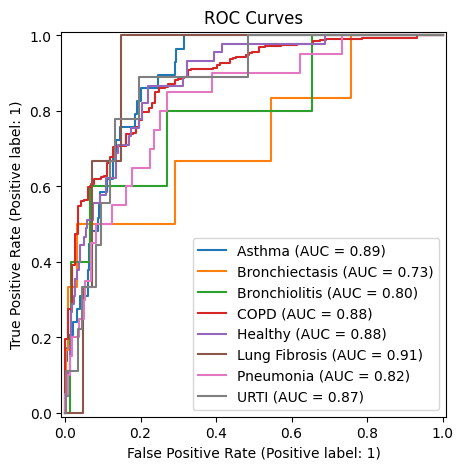

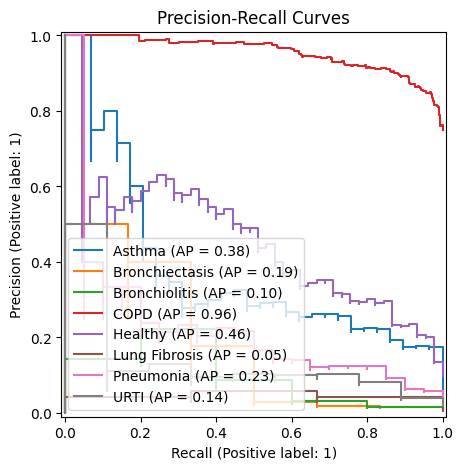

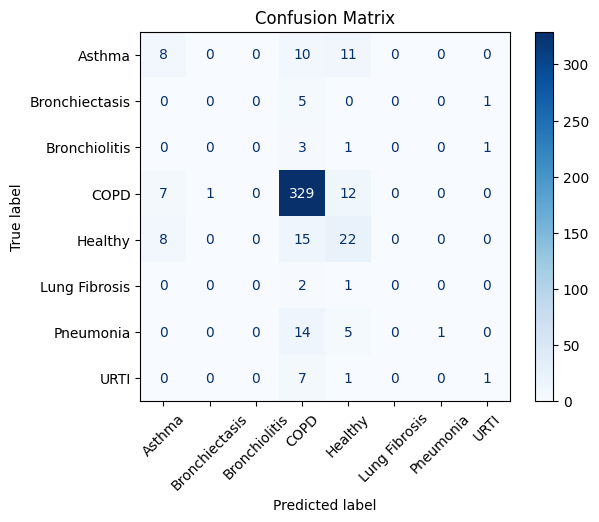

In [13]:
evaluate_model(model)

### Phase

In [ ]:
hparams["experiment"] = "inception_v3_combined_8-classes_Phase"
hparams["dataset"]["feature_extractor"] = "Phase"
hparams["dataset"]["num_channels"] = 1
model = train_model(hparams)

Experiment hyperparameters:
{'batch_size': 32,
 'checkpoint_mode': 'max',
 'checkpoint_monitor': 'val_f1_macro',
 'criterion': 'CrossEntropyLoss',
 'dataset': {'classes': ['Asthma',
                         'Bronchiectasis',
                         'Bronchiolitis',
                         'COPD',
                         'Healthy',
                         'Lung Fibrosis',
                         'Pneumonia',
                         'URTI'],
             'feature_extractor': 'Phase',
             'name': 'Combined_ICBHI_KAUH',
             'num_channels': 1},
 'early_stop_mode': 'max',
 'early_stop_monitor': 'val_f1_macro',
 'experiment': 'inception_v3_combined_8-classes_Phase',
 'gamma': 0.1,
 'learning_rate': 0.0001,
 'lr_scheduler': 'StepLR',
 'max_epochs': 100,
 'model': {'freeze_layers': False, 'name': 'inception_v3', 'pretrained': None},
 'momentum': None,
 'num_workers': 8,
 'optimizer': 'AdamW',
 'patience': 10,
 'precision': '16-mixed',
 'sampler': None,
 'seed': 42,
 'ste

/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


Model Summary:

Input shape: (32, 1, 1025, 216)


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/leticialopes/Projects/IA901/IA901_Project/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

   | Name           | Type               | Params | Mode  | FLOPs
-------------------------------

Layer (type:depth-idx)                   Output Shape              Param #
LungSoundClassifier                      [32, 8]                   --
├─Inception3: 1-1                        [32, 8]                   --
│    └─BasicConv2d: 2-1                  [32, 32, 512, 107]        --
│    │    └─Conv2d: 3-1                  [32, 32, 512, 107]        288
│    │    └─BatchNorm2d: 3-2             [32, 32, 512, 107]        64
│    └─BasicConv2d: 2-2                  [32, 32, 510, 105]        --
│    │    └─Conv2d: 3-3                  [32, 32, 510, 105]        9,216
│    │    └─BatchNorm2d: 3-4             [32, 32, 510, 105]        64
│    └─BasicConv2d: 2-3                  [32, 64, 510, 105]        --
│    │    └─Conv2d: 3-5                  [32, 64, 510, 105]        18,432
│    │    └─BatchNorm2d: 3-6             [32, 64, 510, 105]        128
│    └─MaxPool2d: 2-4                    [32, 64, 254, 52]         --
│    └─BasicConv2d: 2-5                  [32, 80, 254, 52]         --
│    │

...

Epoch 35, global step 4212: 'val_f1_macro' was not in top 3


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_f1_macro did not improve in the last 10 records. Best score: 0.138. Signaling Trainer to stop.
Epoch 36, global step 4329: 'val_f1_macro' was not in top 3
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         Test metric                 DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       test_Asthma_f1             0.10526315867900848
    test_Asthma_precision         0.2222222238779068
     test_Asthma_recall           0.06896551698446274
   test_Bronchiectasis_f1                 0.0
test_Bronchiectasis_precision             0.0
 test_Bronchiectasis_recall               0.0
    test_Bronchiolitis_f1                 0.0
test_Bronchiolitis_precision              0.0
  test_Bronchiolitis_recall               0.0
        test_COPD_f1              0.8521303534507751
     test_COPD_precision          0.7572383284568787
      test_COPD_recall            0.9742120504379272
       test_Healthy_f1            0.0416666679084301
   test_Healthy_precision         0.3333333432674408
     t

Classification Report:
                precision    recall  f1-score   support

        Asthma       0.22      0.07      0.11        29
Bronchiectasis       0.00      0.00      0.00         6
 Bronchiolitis       0.00      0.00      0.00         5
          COPD       0.76      0.97      0.85       349
       Healthy       0.33      0.02      0.04        45
 Lung Fibrosis       0.00      0.00      0.00         3
     Pneumonia       0.00      0.00      0.00        20
          URTI       0.00      0.00      0.00         9

      accuracy                           0.74       466
     macro avg       0.16      0.13      0.12       466
  weighted avg       0.61      0.74      0.65       466



/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

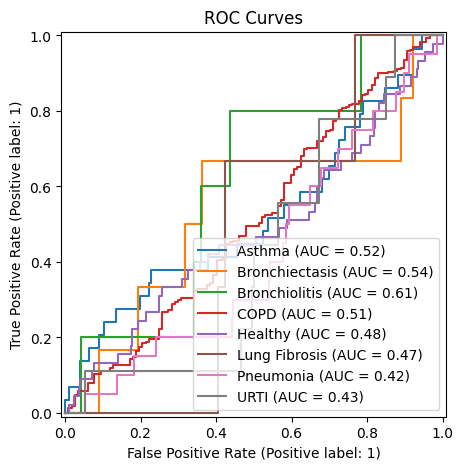

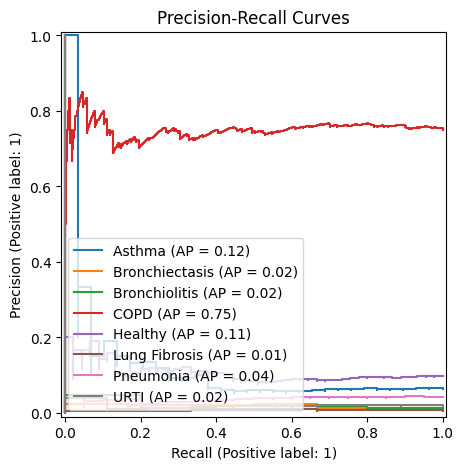

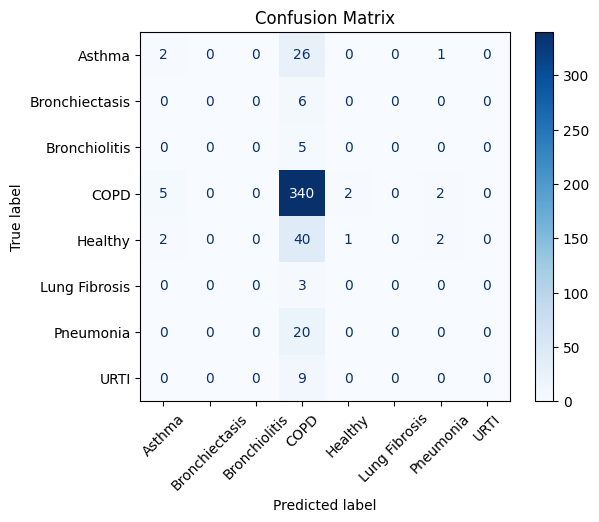

In [7]:
evaluate_model(model)

### Combination of features
The combination is a stack of MelSpectogram, MFCC and Chroma features, resulting in a 3-channel matrix.

In [ ]:
hparams["experiment"] = "inception_v3_combined_8-classes_Stack_MelSpectrogram_MFCC_Chroma"
hparams["dataset"]["feature_extractor"] = "Stack_MelSpectrogram_MFCC_Chroma"
hparams["dataset"]["num_channels"] = 3
model = train_model(hparams)

Experiment hyperparameters:
{'batch_size': 32,
 'checkpoint_mode': 'max',
 'checkpoint_monitor': 'val_f1_macro',
 'criterion': 'CrossEntropyLoss',
 'dataset': {'classes': ['Asthma',
                         'Bronchiectasis',
                         'Bronchiolitis',
                         'COPD',
                         'Healthy',
                         'Lung Fibrosis',
                         'Pneumonia',
                         'URTI'],
             'feature_extractor': 'Stack_MelSpectrogram_MFCC_Chroma',
             'name': 'Combined_ICBHI_KAUH',
             'num_channels': 3},
 'early_stop_mode': 'max',
 'early_stop_monitor': 'val_f1_macro',
 'experiment': 'inception_v3_combined_8-classes_Stack_MelSpectrogram_MFCC_Chroma',
 'gamma': 0.1,
 'learning_rate': 0.0001,
 'lr_scheduler': 'StepLR',
 'max_epochs': 100,
 'model': {'freeze_layers': False, 'name': 'inception_v3', 'pretrained': None},
 'momentum': None,
 'num_workers': 8,
 'optimizer': 'AdamW',
 'patience': 10,
 'precis

/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/leticialopes/Projects/IA901/IA901_Project/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_D

Model Summary:

Input shape: (32, 3, 128, 216)
Layer (type:depth-idx)                   Output Shape              Param #
LungSoundClassifier                      [32, 8]                   --
├─Inception3: 1-1                        [32, 8]                   --
│    └─BasicConv2d: 2-1                  [32, 32, 63, 107]         --
│    │    └─Conv2d: 3-1                  [32, 32, 63, 107]         864
│    │    └─BatchNorm2d: 3-2             [32, 32, 63, 107]         64
│    └─BasicConv2d: 2-2                  [32, 32, 61, 105]         --
│    │    └─Conv2d: 3-3                  [32, 32, 61, 105]         9,216
│    │    └─BatchNorm2d: 3-4             [32, 32, 61, 105]         64
│    └─BasicConv2d: 2-3                  [32, 64, 61, 105]         --
│    │    └─Conv2d: 3-5                  [32, 64, 61, 105]         18,432
│    │    └─BatchNorm2d: 3-6             [32, 64, 61, 105]         128
│    └─MaxPool2d: 2-4                    [32, 64, 30, 52]          --
│    └─BasicConv2d: 2-5      

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

Epoch 26, global step 3159: 'val_f1_macro' was not in top 3


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_f1_macro did not improve in the last 10 records. Best score: 0.555. Signaling Trainer to stop.
Epoch 27, global step 3276: 'val_f1_macro' was not in top 3
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         Test metric                 DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       test_Asthma_f1             0.5098039507865906
    test_Asthma_precision         0.5909090638160706
     test_Asthma_recall           0.4482758641242981
   test_Bronchiectasis_f1         0.2857142984867096
test_Bronchiectasis_precision             1.0
 test_Bronchiectasis_recall       0.1666666716337204
    test_Bronchiolitis_f1                0.75
test_Bronchiolitis_precision              1.0
  test_Bronchiolitis_recall       0.6000000238418579
        test_COPD_f1              0.9515669345855713
     test_COPD_precision          0.9461756348609924
      test_COPD_recall            0.9570200443267822
       test_Healthy_f1            0.6194690465927124
   test_Healthy_precision         0.5147

Classification Report:
                precision    recall  f1-score   support

        Asthma       0.59      0.45      0.51        29
Bronchiectasis       1.00      0.17      0.29         6
 Bronchiolitis       1.00      0.60      0.75         5
          COPD       0.95      0.96      0.95       349
       Healthy       0.51      0.78      0.62        45
 Lung Fibrosis       0.00      0.00      0.00         3
     Pneumonia       0.75      0.45      0.56        20
          URTI       0.00      0.00      0.00         9

      accuracy                           0.85       466
     macro avg       0.60      0.42      0.46       466
  weighted avg       0.85      0.85      0.84       466



/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

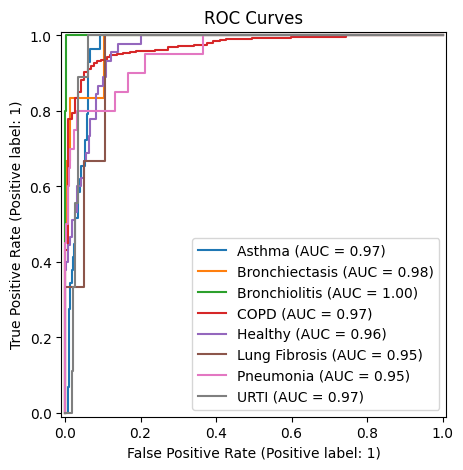

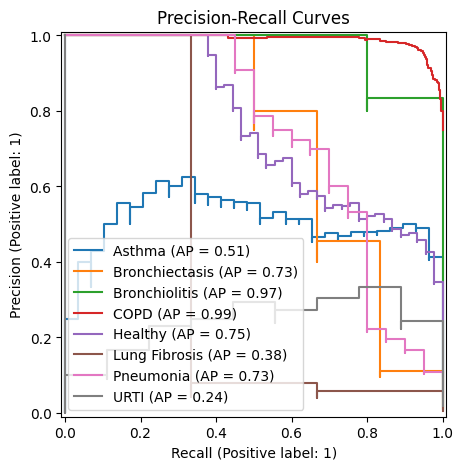

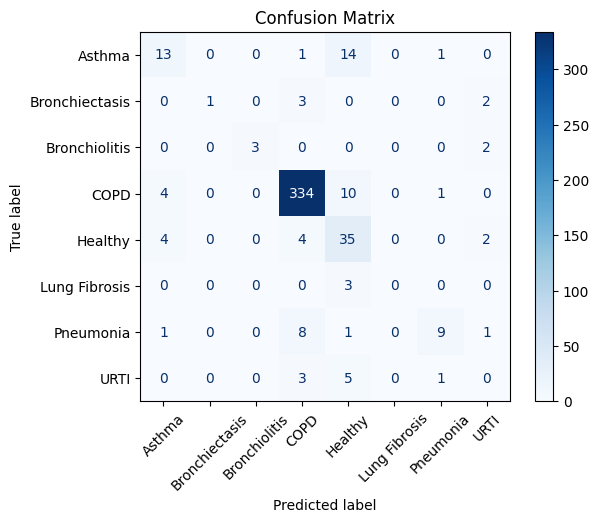

In [18]:
evaluate_model(model)

In [ ]:
%tensorboard --logdir {LOGS_FOLDER}

## Comparison

,experiment,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
4,Chroma,0.7747,0.3688,0.2336,0.2394,0.7511,0.7747,0.7412
2,MFCC,0.8841,0.6627,0.5795,0.6151,0.8726,0.8841,0.8762
3,MFCCDelta,0.8090,0.3275,0.2988,0.2880,0.7825,0.8090,0.7861
1,MelSpectogram,0.8112,0.4080,0.3153,0.3315,0.7847,0.8112,0.7920
5,Phase,0.7361,0.1641,0.1332,0.1249,0.6131,0.7361,0.6488
0,STFT,0.8412,0.5903,0.4196,0.4589,0.8330,0.8412,0.8318
6,Stack_MelSpectrogram_MFCC_Chroma,0.8476,0.6002,0.4250,0.4599,0.8509,0.8476,0.8401


,class,support
0,Asthma,29
1,Bronchiectasis,6
2,Bronchiolitis,5
3,COPD,349
4,Healthy,45
5,Lung Fibrosis,3
6,Pneumonia,20
7,URTI,9


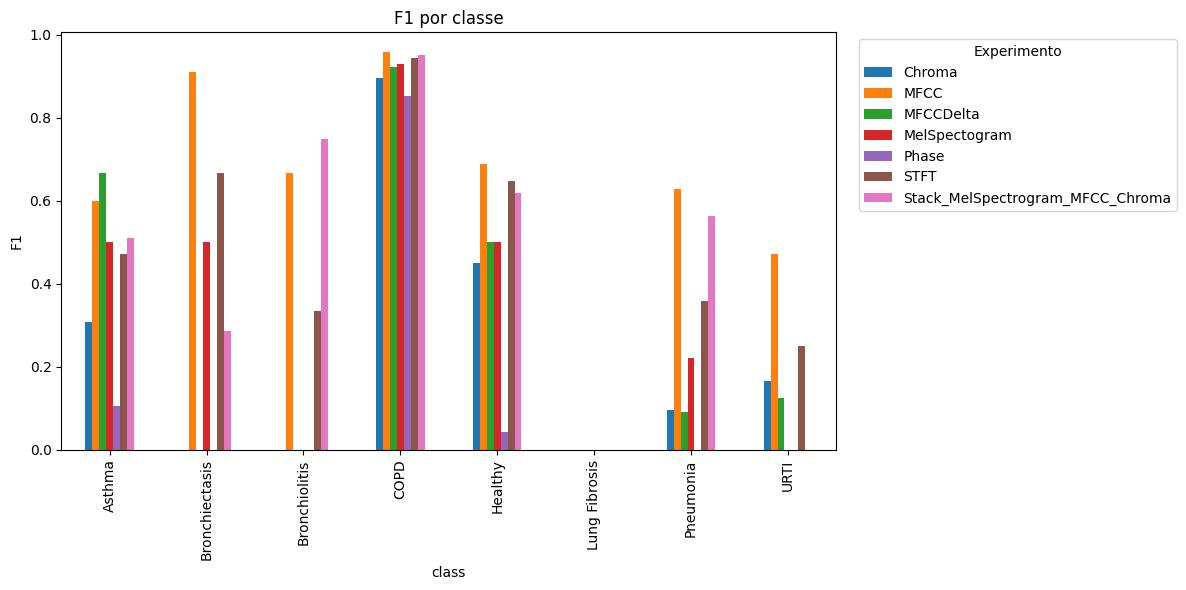

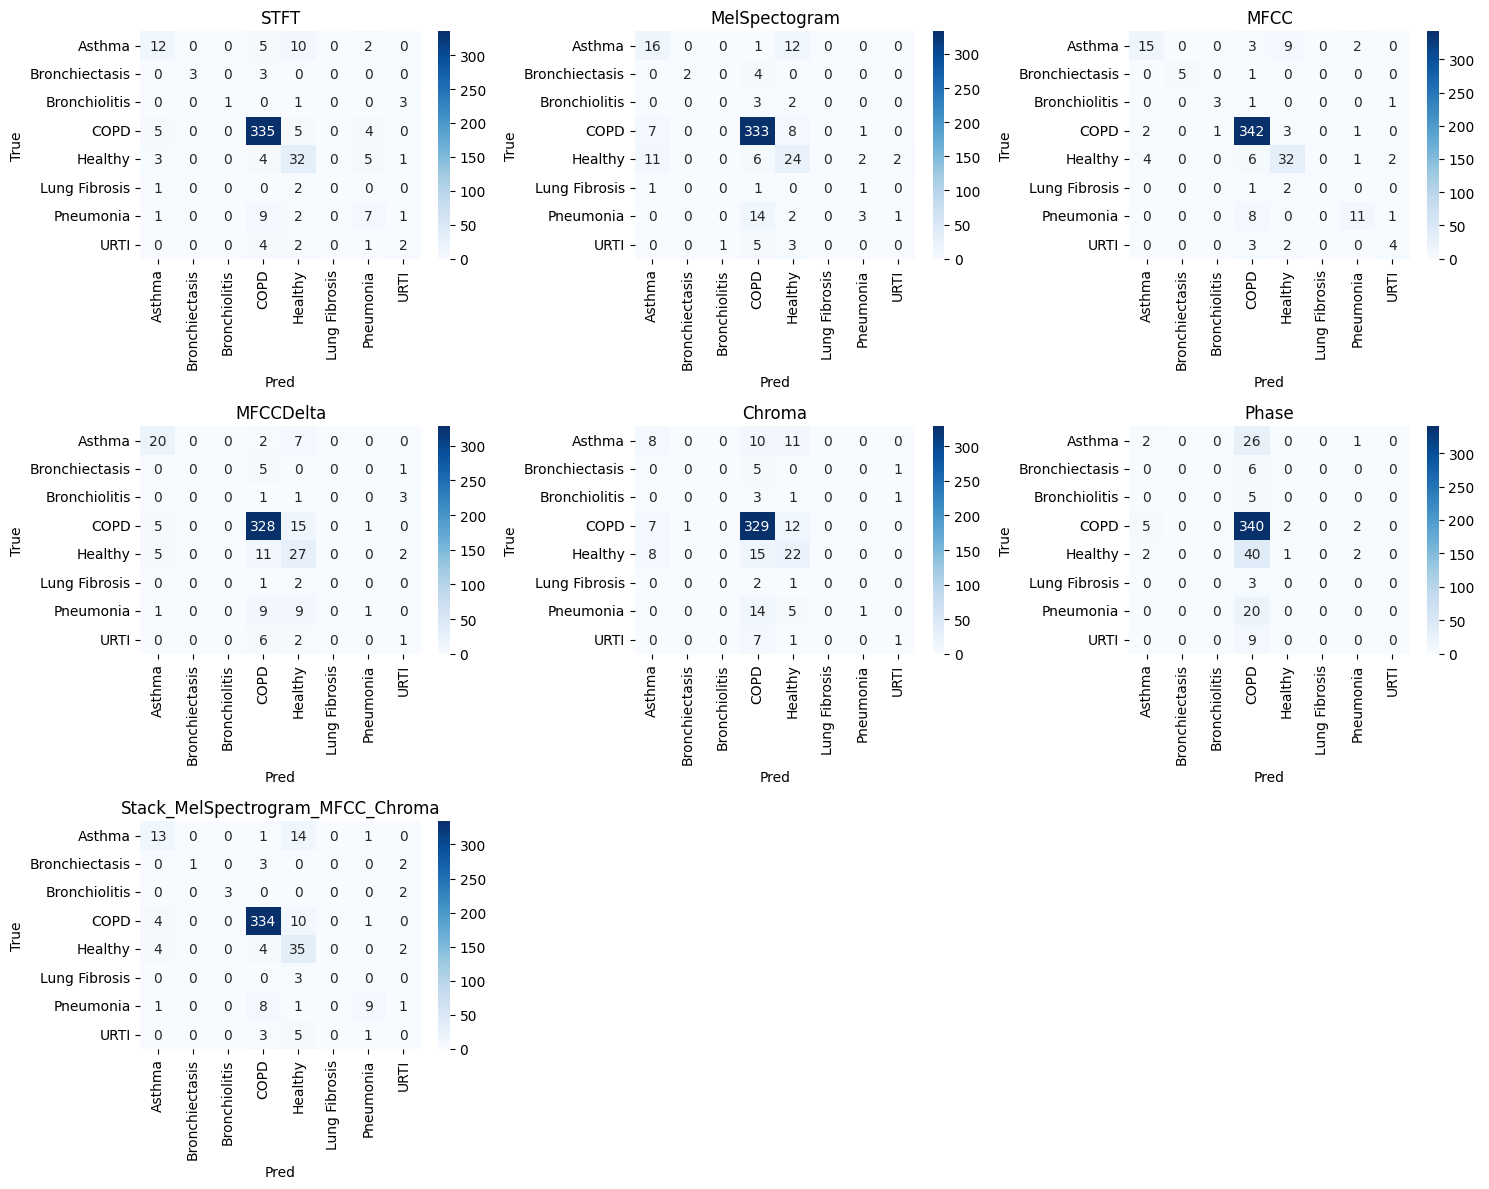

In [2]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
)

# Configure paths to the CSV result files
csv_paths = [
    "../results/inception_v3_combined_8-classes_STFT_results.csv",
    "../results/inception_v3_combined_8-classes_MelSpectogram_results.csv",
    "../results/inception_v3_combined_8-classes_MFCC_results.csv",
    "../results/inception_v3_combined_8-classes_MFCCDelta_results.csv",
    "../results/inception_v3_combined_8-classes_Chroma_results.csv",
    "../results/inception_v3_combined_8-classes_Phase_results.csv",
    "../results/inception_v3_combined_8-classes_Stack_MelSpectrogram_MFCC_Chroma_results.csv",
]

# Collect metrics and per-class F1
summary_rows = []
per_class_f1_rows = []
support_rows = []
conf_matrices = []

for csv_path in csv_paths:
    csv_path = Path(csv_path)
    df = pd.read_csv(csv_path)
    experiment_name = csv_path.stem.split("_results")[0]
    experiment_name = experiment_name.split("inception_v3_combined_8-classes_")[-1]
    if "target" not in df.columns or "pred" not in df.columns:
        continue

    y_true = df["target"].astype(int).to_numpy()
    y_pred = df["pred"].astype(int).to_numpy()

    prob_cols = [c for c in df.columns if c.startswith("prob_")]
    class_names = [c.replace("prob_", "") for c in prob_cols]

    if class_names:
        labels = list(range(len(class_names)))
    else:
        labels = sorted(np.unique(np.concatenate([y_true, y_pred])))
        class_names = [str(l) for l in labels]

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, average=None, zero_division=0
    )
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, average="macro", zero_division=0
    )

    precision_we, recall_we, f1_we, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, average="weighted", zero_division=0
    )

    summary_rows.append(
        {
            "experiment": experiment_name,
            "accuracy": f"{acc:.4f}",
            "precision_macro": f"{precision_macro:.4f}",
            "recall_macro": f"{recall_macro:.4f}",
            "f1_macro": f"{f1_macro:.4f}",
            "precision_weighted": f"{precision_we:.4f}",
            "recall_weighted": f"{recall_we:.4f}",
            "f1_weighted": f"{f1_we:.4f}",
        }
    )

    for cls_name, f1_cls in zip(class_names, f1):
        per_class_f1_rows.append(
            {"experiment": experiment_name, "class": cls_name, "f1": f1_cls}
        )


    cm = confusion_matrix(y_true, y_pred, labels=labels)
    conf_matrices.append((experiment_name, cm, class_names))

# Table with overall metrics
for cls_name, sup in zip(class_names, support):
    support_rows.append(
        {"class": cls_name, "support": sup}
    )
summary_df = pd.DataFrame(summary_rows).sort_values("experiment")
display(summary_df)

support_df = pd.DataFrame(support_rows)
display(support_df)

# F1 per class plot
if per_class_f1_rows:
    f1_df = pd.DataFrame(per_class_f1_rows)
    f1_pivot = f1_df.pivot(index="class", columns="experiment", values="f1")
    ax = f1_pivot.plot(kind="bar", figsize=(12, 6))
    ax.set_ylabel("F1")
    ax.set_title("F1 por classe")
    ax.legend(title="Experimento", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# Confusion matrices in one image
if conf_matrices:
    n = len(conf_matrices)
    cols = 3
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
    axes = np.array(axes).reshape(-1)

    for ax, (name, cm, class_names) in zip(axes, conf_matrices):
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names,
            ax=ax,
        )
        ax.set_title(name)
        ax.set_xlabel("Pred")
        ax.set_ylabel("True")
        ax.tick_params(axis="x", rotation=90)
        ax.tick_params(axis="y", rotation=0)

    for ax in axes[len(conf_matrices) :]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()